# Realistic City Benchmarks

This notebook benchmarks increasingly large realistic city networks from `benchmarks/networks/` and charts runtime trends.

It supports:
- EPANETx CPU binary (defaults to `build/bin/epanetx`)
- Base EPANET binary (`../EPANET/build/bin/runepanet`) if available

In [29]:
from pathlib import Path
import csv
import re
import statistics
import subprocess
import time

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'CMakeLists.txt').exists() and (p / 'src').is_dir() and (p / 'benchmarks' / 'networks').is_dir():
            return p
    raise RuntimeError(f'Could not locate EPANETx repo root from {start}')

ROOT = find_repo_root(Path.cwd().resolve())
NETWORK_DIR = ROOT / 'benchmarks' / 'networks'
RESULTS_DIR = ROOT / 'benchmarks' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def first_existing(*paths: Path) -> Path:
    for p in paths:
        if p.exists():
            return p
    return paths[0]

EPANETX_CPU = first_existing(
    ROOT / 'build-release' / 'bin' / 'epanetx',
    ROOT / 'build' / 'bin' / 'epanetx',
    ROOT / 'bin' / 'epanetx',
)
EPANET_BASE = first_existing(
    ROOT.parent / 'EPANET' / 'build-release' / 'bin' / 'runepanet',
    ROOT.parent / 'EPANET' / 'build' / 'bin' / 'runepanet',
    ROOT.parent / 'EPANET' / 'bin' / 'runepanet',
    ROOT / 'bin' / 'runepanet',
)

print('CWD         :', Path.cwd().resolve())
print('ROOT        :', ROOT)
print('NETWORK_DIR :', NETWORK_DIR, 'exists=', NETWORK_DIR.exists())
print('EPANETx CPU :', EPANETX_CPU, 'exists=', EPANETX_CPU.exists())
print('EPANET base :', EPANET_BASE, 'exists=', EPANET_BASE.exists())

if plt is None:
    print('matplotlib is not installed. Install in notebook: %pip install matplotlib')
if pd is None:
    print('pandas is not installed. Install in notebook: %pip install pandas')

CWD         : /Users/matthewdowns/Workspace/NEER/EPANETx/benchmarks
ROOT        : /Users/matthewdowns/Workspace/NEER/EPANETx
NETWORK_DIR : /Users/matthewdowns/Workspace/NEER/EPANETx/benchmarks/networks exists= True
EPANETx CPU : /Users/matthewdowns/Workspace/NEER/EPANETx/build-release/bin/epanetx exists= True
EPANET base : /Users/matthewdowns/Workspace/NEER/EPANET/build-release/bin/runepanet exists= True


In [22]:
size_re = re.compile(r'.*_(\d+)x(\d+)\.inp$')

def network_size(path: Path):
    m = size_re.match(path.name)
    if not m:
        return (0, 0)
    return (int(m.group(1)), int(m.group(2)))

inputs = sorted(NETWORK_DIR.glob('realistic_city_*x*.inp'), key=network_size)
if not inputs:
    raise RuntimeError(f'No benchmark inputs found in {NETWORK_DIR}')

for p in inputs:
    r, c = network_size(p)
    print(f'- {p.name}: {r}x{c}')

- realistic_city_60x60.inp: 60x60
- realistic_city_90x90.inp: 90x90
- realistic_city_120x120.inp: 120x120


In [31]:
def percentile(values, p):
    if not values:
        return None
    xs = sorted(values)
    if len(xs) == 1:
        return xs[0]
    pos = (len(xs) - 1) * p
    lo = int(pos)
    hi = min(lo + 1, len(xs) - 1)
    frac = pos - lo
    return xs[lo] * (1.0 - frac) + xs[hi] * frac

def run_timed(exe: Path, inp: Path, run_label: str, repeats: int = 10, warmup: bool = True):
    if not exe.exists():
        return None

    run_dir = RESULTS_DIR / run_label
    run_dir.mkdir(parents=True, exist_ok=True)

    if warmup:
        warm_rpt = run_dir / f'{inp.stem}_warm.rpt'
        warm_out = run_dir / f'{inp.stem}_warm.out'
        subprocess.run([str(exe), str(inp), str(warm_rpt), str(warm_out)], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    times = []
    for i in range(repeats):
        rpt = run_dir / f'{inp.stem}_{i}.rpt'
        out = run_dir / f'{inp.stem}_{i}.out'
        t0 = time.perf_counter()
        subprocess.run([str(exe), str(inp), str(rpt), str(out)], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        times.append(time.perf_counter() - t0)

    return {
        'avg_s': statistics.mean(times),
        'median_s': statistics.median(times),
        'p95_s': percentile(times, 0.95),
        'stdev_s': statistics.pstdev(times) if len(times) > 1 else 0.0,
        'min_s': min(times),
        'max_s': max(times),
        'repeats': repeats,
        'times': times,
    }

In [32]:
REPEATS = 10
results = []

for inp in inputs:
    rows, cols = network_size(inp)
    nx = run_timed(EPANETX_CPU, inp, run_label='epanetx', repeats=REPEATS)
    base = run_timed(EPANET_BASE, inp, run_label='epanet', repeats=REPEATS) if EPANET_BASE.exists() else None

    row = {
        'network': inp.name,
        'rows': rows,
        'cols': cols,
        'nodes_approx': rows * cols,
        'epanetx_cpu_avg_s': nx['avg_s'] if nx else None,
        'epanetx_cpu_median_s': nx['median_s'] if nx else None,
        'epanetx_cpu_p95_s': nx['p95_s'] if nx else None,
        'epanetx_cpu_stdev_s': nx['stdev_s'] if nx else None,
        'epanetx_cpu_min_s': nx['min_s'] if nx else None,
        'epanetx_cpu_max_s': nx['max_s'] if nx else None,
        'epanet_base_avg_s': base['avg_s'] if base else None,
        'epanet_base_median_s': base['median_s'] if base else None,
        'epanet_base_p95_s': base['p95_s'] if base else None,
        'epanet_base_stdev_s': base['stdev_s'] if base else None,
        'epanet_base_min_s': base['min_s'] if base else None,
        'epanet_base_max_s': base['max_s'] if base else None,
        'speedup_base_over_epanetx': (base['avg_s'] / nx['avg_s']) if (base and nx and nx['avg_s'] > 0) else None,
        'speedup_base_over_epanetx_median': (base['median_s'] / nx['median_s']) if (base and nx and nx['median_s'] > 0) else None,
    }
    results.append(row)

csv_path = RESULTS_DIR / 'realistic_city_benchmark.csv'
with csv_path.open('w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(results[0].keys()))
    w.writeheader()
    w.writerows(results)

print(f'Wrote {csv_path}')

if pd is not None:
    df = pd.DataFrame(results).sort_values(['rows', 'cols'])
    display(df)
else:
    for r in results:
        print(r)

Wrote /Users/matthewdowns/Workspace/NEER/EPANETx/benchmarks/results/realistic_city_benchmark.csv


,network,rows,cols,nodes_approx,epanetx_cpu_avg_s,epanetx_cpu_median_s,epanetx_cpu_p95_s,epanetx_cpu_stdev_s,epanetx_cpu_min_s,epanetx_cpu_max_s,epanet_base_avg_s,epanet_base_median_s,epanet_base_p95_s,epanet_base_stdev_s,epanet_base_min_s,epanet_base_max_s,speedup_base_over_epanetx,speedup_base_over_epanetx_median
0,realistic_city_60x60.inp,60,60,3600,0.120124,0.118655,0.126232,0.003567,0.116675,0.127134,0.126179,0.119747,0.152755,0.016054,0.118608,0.173713,1.050407,1.009199
1,realistic_city_90x90.inp,90,90,8100,0.487318,0.478893,0.527586,0.024822,0.474813,0.561057,0.503935,0.491468,0.564080,0.031664,0.478229,0.587879,1.034100,1.026260
2,realistic_city_120x120.inp,120,120,14400,1.448145,1.446111,1.467650,0.012335,1.430373,1.479818,1.547267,1.527103,1.727604,0.106246,1.439325,1.807542,1.068448,1.056007


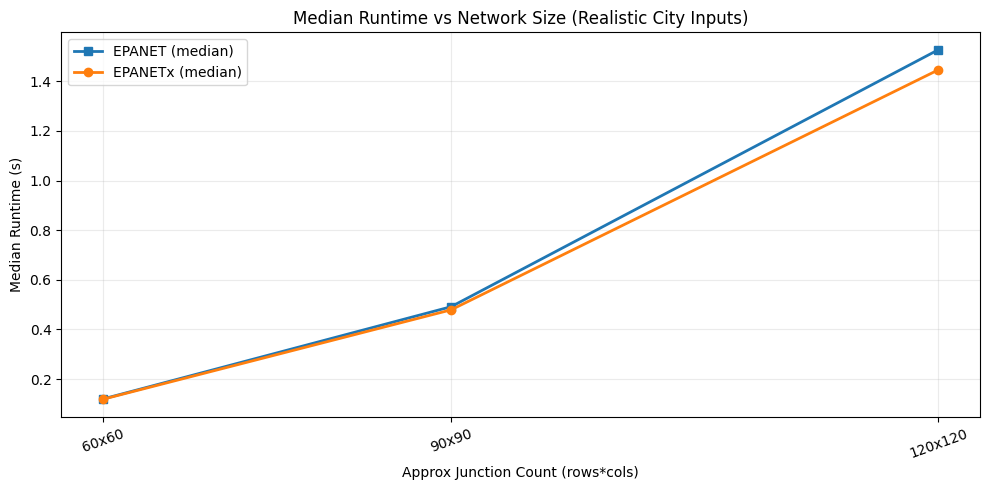

In [33]:
if plt is None:
    raise RuntimeError('matplotlib is required for charting. Run: %pip install matplotlib')

data = sorted(results, key=lambda r: (r['rows'], r['cols']))
x = [r['nodes_approx'] for r in data]
x_labels = [f"{r['rows']}x{r['cols']}" for r in data]
y_epanetx = [r['epanetx_cpu_median_s'] for r in data]
y_base = [r['epanet_base_median_s'] for r in data if r['epanet_base_median_s'] is not None]
x_base = [r['nodes_approx'] for r in data if r['epanet_base_median_s'] is not None]

plt.figure(figsize=(10, 5))
if x_base:
    plt.plot(x_base, y_base, marker='s', linewidth=2, label='EPANET (median)')
plt.plot(x, y_epanetx, marker='o', linewidth=2, label='EPANETx (median)')
plt.title('Median Runtime vs Network Size (Realistic City Inputs)')
plt.xlabel('Approx Junction Count (rows*cols)')
plt.ylabel('Median Runtime (s)')
plt.grid(True, alpha=0.25)
plt.legend()
plt.xticks(x, x_labels, rotation=20)
plt.tight_layout()
plt.show()

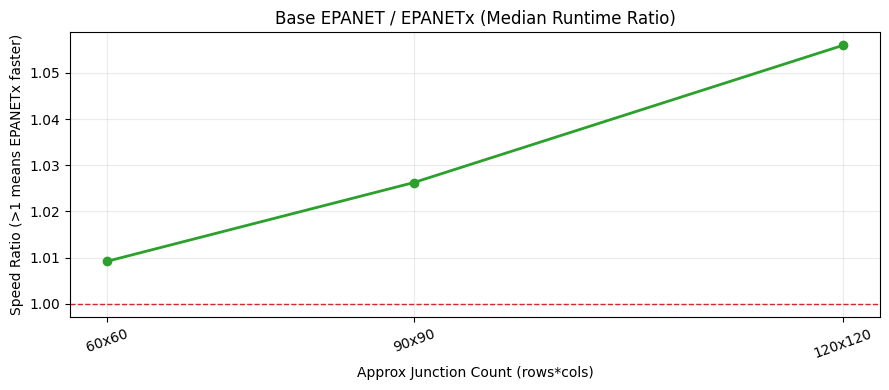

In [34]:
speed_rows = [r for r in data if r['speedup_base_over_epanetx_median'] is not None]
if speed_rows:
    sx = [r['nodes_approx'] for r in speed_rows]
    sy = [r['speedup_base_over_epanetx_median'] for r in speed_rows]
    sl = [f"{r['rows']}x{r['cols']}" for r in speed_rows]

    plt.figure(figsize=(9, 4))
    plt.plot(sx, sy, marker='o', linewidth=2, color='tab:green')
    plt.axhline(1.0, color='tab:red', linestyle='--', linewidth=1)
    plt.title('Base EPANET / EPANETx (Median Runtime Ratio)')
    plt.xlabel('Approx Junction Count (rows*cols)')
    plt.ylabel('Speed Ratio (>1 means EPANETx faster)')
    plt.grid(True, alpha=0.25)
    plt.xticks(sx, sl, rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print('Base EPANET binary not found; skipping ratio chart.')